In [1]:
from datetime import datetime
import math
import numpy as np
from tbparse import SummaryReader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

2026-01-08 17:46:35.207546: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 17:46:36.451538: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 17:46:40.717788: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/boran/DRe-SCale/venv/lib/python3.12/site-packages/ker

In [5]:
# 1. Setup the reader (same as before)
log_dir = "./logs/evaluation/20260107-182325/PPO_LSTM_Run1"  # Keep your timestamp
reader = SummaryReader(log_dir, pivot=True)

# 2. DEBUG: Ask it what tags it found
print("Found Tags:", reader.get_tags())

# 3. TRY THIS: Read from 'tensors' instead of 'scalars'
df = reader.tensors 

print("\nData Found:")
print(df.head())

Found Tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': [], 'tensors': ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'n-step_reward', 'episodic_reward', 'reward summary'], 'hparams': [], 'text': []}

Data Found:
   step  action  avg_execution_time     cpu  episode  \
0     0     2.0               0.495  0.0225      0.0   
1     1     1.0               1.565  0.0090      0.0   
2     2     1.0               0.438  0.0349      0.0   
3     3     1.0               0.007  0.0089      0.0   
4     4     2.0               0.009  0.0158      0.0   

                  episodic_reward     mem  n-step_reward  replicas  requests  \
0                    70030.820312  0.1447    3776.590088       6.0       7.0   
1     [70030.8203125, 74789.0625]  0.1443    7492.919922       7.0       1.0   
2       [74789.0625, 72692.03125]  0.1422    7489.959961       8.0      15.0   
3    [74456.0234375, 72692.03125]  0.1420    7485.890137       9.0  

In [6]:
import os

# Use the path you tried
target_dir = "./logs/evaluation/20260107-182325/PPO_LSTM_Run1"

print(f"Checking: {target_dir}")
if os.path.exists(target_dir):
    files = os.listdir(target_dir)
    print(f"Files found: {files}")
    for f in files:
        full_path = os.path.join(target_dir, f)
        size = os.path.getsize(full_path)
        print(f" - {f}: {size} bytes")
else:
    print("❌ Directory not found. Please check the timestamp folder name in 'logs/evaluation/'")

Checking: ./logs/evaluation/20260107-182325/PPO_LSTM_Run1
Files found: ['events.out.tfevents.1767799405.TardisV3.67559.0.v2']
 - events.out.tfevents.1767799405.TardisV3.67559.0.v2: 124519 bytes


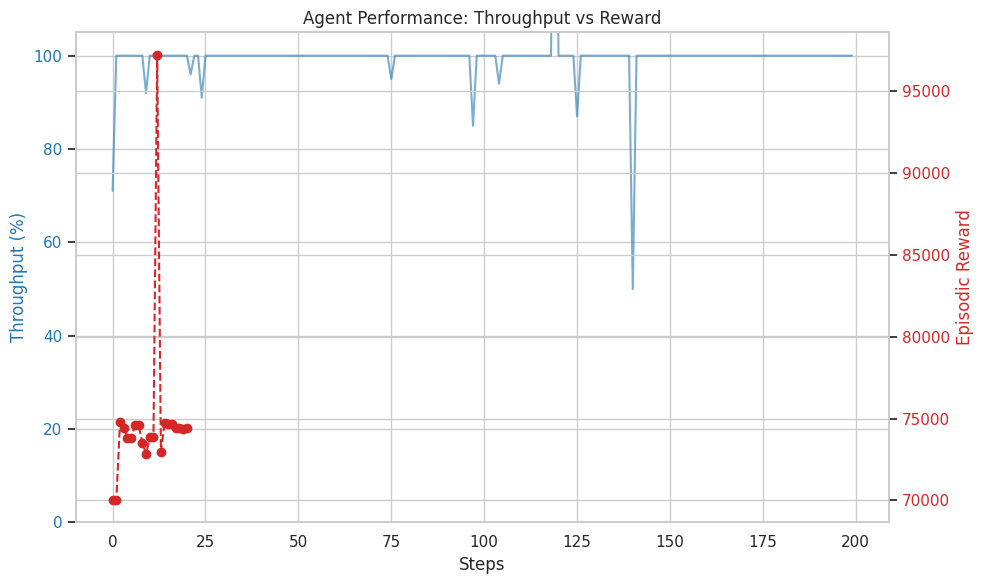

In [7]:
# 1. Load the data
df = reader.tensors
df = df.reset_index()  # Make 'step' a regular column

# --- HELPER FUNCTION TO FIX THE "LIST" ERROR ---
def clean_metric(series):
    """
    Extracts scalar values if they are wrapped in lists or arrays.
    Example: Converts [100.0] -> 100.0
    """
    def extract(x):
        # If it's a list or numpy array, grab the first item
        if isinstance(x, (list, np.ndarray)):
            return x[0] if len(x) > 0 else 0
        # If it's a numpy 0-d array (scalar), convert to float
        if hasattr(x, 'item'):
            return x.item()
        return x

    return series.apply(extract)
# -----------------------------------------------

# 2. Get Columns and Clean Them
steps = df['step']

if 'throughput' in df.columns:
    # Clean the throughput column!
    throughput = clean_metric(df['throughput'])
else:
    print("Warning: 'throughput' not found. Plotting zeros.")
    throughput = [0] * len(steps)

if 'episodic_reward' in df.columns:
    # Clean the reward column!
    reward = clean_metric(df['episodic_reward'])
else:
    print("Warning: 'episodic_reward' not found. Plotting zeros.")
    reward = [0] * len(steps)

# 3. Create the dual-axis plot
fig, ax1 = plt.subplots()

# Plot Throughput (Blue)
color = 'tab:blue'
ax1.set_xlabel('Steps')
ax1.set_ylabel('Throughput (%)', color=color)
ax1.plot(steps, throughput, color=color, alpha=0.6, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 105)

# Plot Reward (Red) on the right axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Episodic Reward', color=color)
ax2.plot(steps, reward, color=color, marker='o', linestyle='--', label='Reward')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Agent Performance: Throughput vs Reward')
fig.tight_layout()
plt.show()

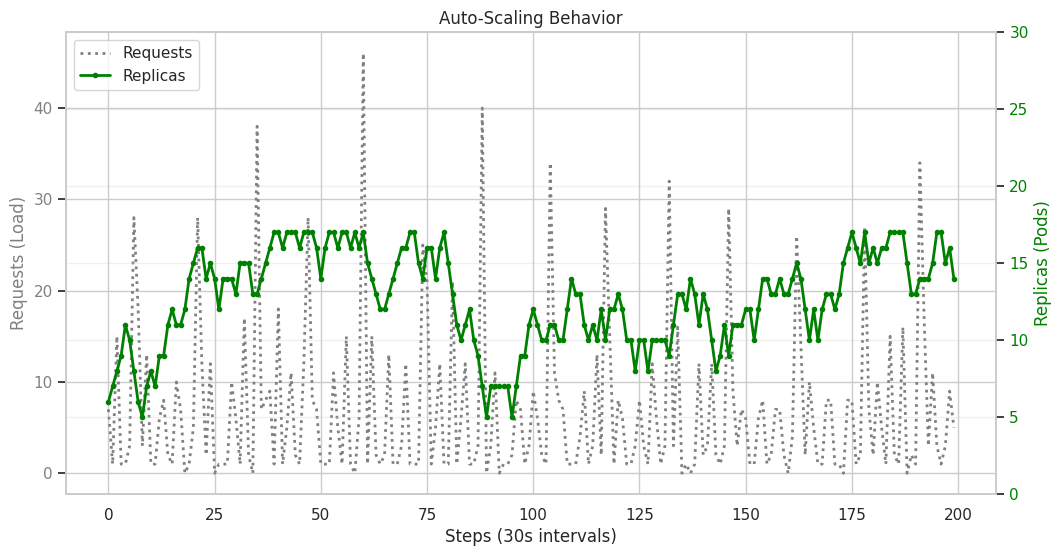

In [8]:
# Ensure we use the cleaned dataframe from the previous step
# (Assuming 'df' is loaded and 'clean_metric' is defined)

# 1. Prepare the Data
steps = df['step']

# Clean the Replicas and Requests columns
if 'replicas' in df.columns:
    replicas = clean_metric(df['replicas'])
else:
    print("Warning: 'replicas' column missing.")
    replicas = [0] * len(steps)

if 'requests' in df.columns:
    requests = clean_metric(df['requests'])
else:
    print("Warning: 'requests' column missing.")
    requests = [0] * len(steps)

# 2. Create the Plot
plt.figure(figsize=(12, 6))

# Plot Requests (The Load) on the Left Axis
ax1 = plt.gca() # Get current axis
ax1.set_xlabel('Steps (30s intervals)')
ax1.set_ylabel('Requests (Load)', color='grey')
# Use a dotted line for requests to make it distinct
line1 = ax1.plot(steps, requests, label='Requests', color='grey', linestyle=':', linewidth=2)
ax1.tick_params(axis='y', labelcolor='grey')

# Plot Replicas (The Agent's Response) on the Right Axis
ax2 = ax1.twinx()
ax2.set_ylabel('Replicas (Pods)', color='green')
# Use a solid green line for the agent's scaling decisions
line2 = ax2.plot(steps, replicas, label='Replicas', color='green', linewidth=2, marker='.')
ax2.tick_params(axis='y', labelcolor='green')

# Set limits for replicas (0 to Max Pods + small buffer)
# You defined MAX_PODS = 24 in your environment
ax2.set_ylim(0, 30)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Auto-Scaling Behavior')
plt.grid(True, alpha=0.3)
plt.show()

Reading logs from: logs/PPO_LSTM_Run2_0
Keys found in logs: ['rollout/ep_len_mean' 'rollout/ep_rew_mean' 'time/fps' 'train/approx_kl'
 'train/clip_fraction' 'train/clip_range' 'train/entropy_loss'
 'train/explained_variance' 'train/learning_rate' 'train/loss'
 'train/policy_gradient_loss' 'train/value_loss']


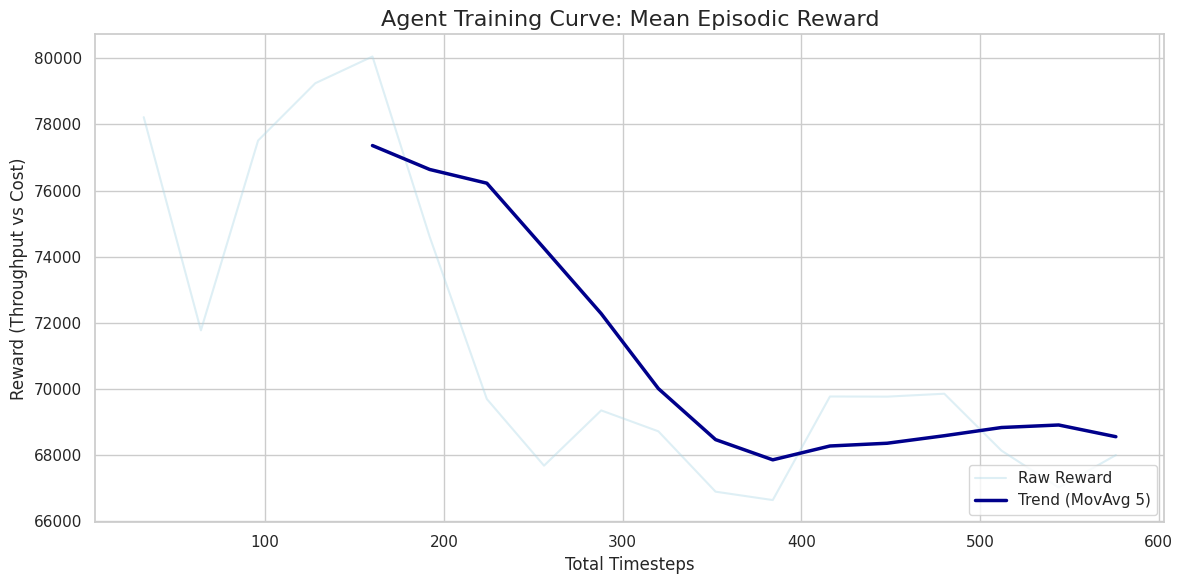

In [ ]:
import os
from tbparse import SummaryReader
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# CHANGE THIS to match the specific folder name inside your 'logs' directory
# Example: "logs/PPO_LSTM_Run1_0" or "logs/PPO_LSTM_Run1_1"
log_dir = "logs/PPO_LSTM_Run2_0" 
# ---------------------

print(f"Reading logs from: {log_dir}")

# 1. Read the data
try:
    reader = SummaryReader(log_dir)
    df = reader.scalars
    print("Keys found in logs:", df['tag'].unique())
except ValueError as e:
    print("Error reading logs. Make sure the folder path is correct and contains an 'events.out.tfevents' file.")
    df = None

# 2. Filter and Plot
if df is not None and 'rollout/ep_rew_mean' in df['tag'].values:
    # Filter for the reward metric
    rewards_df = df[df['tag'] == 'rollout/ep_rew_mean'].copy()
    
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # A. Plot the Raw Data (Light Blue)
    # This shows the exact reward at every logging step
    sns.lineplot(data=rewards_df, x='step', y='value', color='lightblue', alpha=0.4, label='Raw Reward')
    
    # B. Plot a Smoothed Trend Line (Dark Blue)
    # Reinforcement Learning is noisy; this moving average shows the true trend
    window_size = 3 # Adjust this if the line is too jagged
    rewards_df['smoothed'] = rewards_df['value'].rolling(window=window_size).mean()
    sns.lineplot(data=rewards_df, x='step', y='smoothed', color='darkblue', linewidth=2.5, label=f'Trend (MovAvg {window_size})')
    
    # C. Formatting
    plt.title('Agent Training Curve: Mean Episodic Reward', fontsize=16)
    plt.xlabel('Total Timesteps', fontsize=12)
    plt.ylabel('Reward (Throughput vs Cost)', fontsize=12)
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

elif df is not None:
    print("\nWARNING: 'rollout/ep_rew_mean' not found yet.")
    print("Possibilities:")
    print("1. The agent hasn't finished its first episode yet (Wait a few minutes).")
    print("2. The log directory path is pointing to an empty or old run.")

Loaded: evaluation_reward_history_PPO_LSTM_Run1_2.json  |  Episodes: 2


,episode,episodic_reward
0,1,74031.42
1,2,74175.42



Found 2 event file(s)

Logged tags : ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'n-step_reward', 'episodic_reward', 'reward summary']
Total steps : 5180


,step,action,avg_execution_time,cpu,episode,episodic_reward,mem,n-step_reward,replicas,requests,reward summary,throughput
0,0,0.0,0.000,0.0031,0.0,74031.421875,0.1508,7369.669922,24.0,0.0,74031.421875,100.0
1,1,-1.0,0.002,0.0032,0.0,74175.421875,0.1517,7380.939941,23.0,1.0,74103.421875,100.0
2,2,0.0,1.280,0.0069,0.0,74175.421875,0.1533,7381.000000,23.0,1.0,74208.148438,100.0
3,3,-1.0,1.099,0.0032,0.0,72740.593750,0.1543,7391.720215,22.0,15.0,73841.257812,100.0
4,4,-2.0,0.000,0.0273,0.0,74817.320312,0.1589,7412.080078,20.0,0.0,74036.468750,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,0.0,0.000,0.0038,46.0,74566.937500,0.1277,7465.640137,13.0,0.0,73715.250000,100.0
496,496,1.0,0.000,0.0231,46.0,74127.796875,0.1272,7459.629883,14.0,0.0,73708.460938,100.0
497,497,1.0,0.000,0.0183,46.0,74280.109375,0.1269,7452.819824,15.0,0.0,73704.062500,100.0
498,498,-2.0,0.000,0.0036,46.0,95502.226562,0.1283,7465.649902,13.0,0.0,73913.437500,100.0


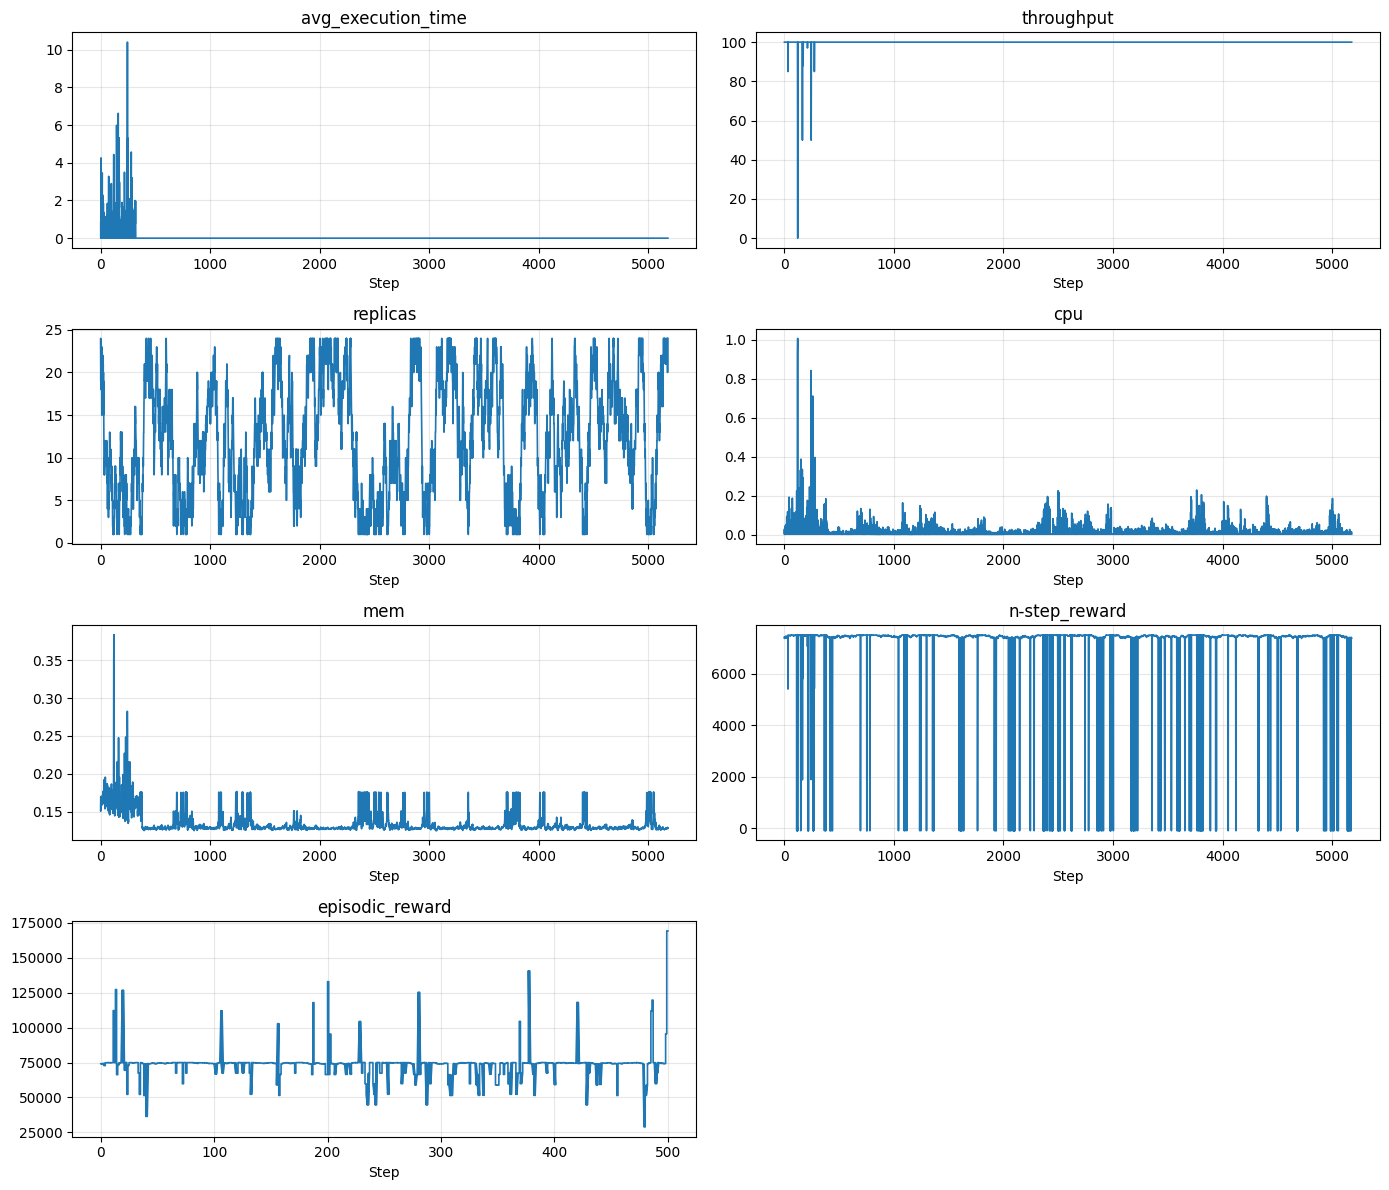

Plot saved → evaluation_summary.png


In [5]:
import json
import glob
import os
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.summary.summary_iterator import summary_iterator

# ── 1. Load JSON reward history ──────────────────────────────────────────────
reward_files = glob.glob("evaluation_reward_history_*.json")
if reward_files:
    latest = max(reward_files, key=os.path.getmtime)
    with open(latest) as f:
        history = json.load(f)
    reward_df = pd.DataFrame({
        'episode': range(1, len(history['reward_history']) + 1),
        'episodic_reward': history['reward_history']
    })
    print(f"Loaded: {latest}  |  Episodes: {history['last_episode']}")
    display(reward_df)
else:
    print("No reward JSON files found.")
    reward_df = pd.DataFrame()

# ── 2. Load TensorBoard event logs ───────────────────────────────────────────
event_files = glob.glob("logs/evaluation/**/events.out.tfevents.*", recursive=True)
print(f"\nFound {len(event_files)} event file(s)")

records = []
for ef in event_files:
    try:
        for event in summary_iterator(ef):
            for value in event.summary.value:
                records.append({
                    'step':  event.step,
                    'wall_time': event.wall_time,
                    'tag':  value.tag,
                    'value': tf.make_ndarray(value.tensor).item()
                             if value.HasField('tensor')
                             else value.simple_value
                })
    except Exception as e:
        print(f"Skipping {ef}: {e}")

events_df = pd.DataFrame(records)

if not events_df.empty:
    # Pivot so each tag becomes a column
    pivot_df = (events_df
                .pivot_table(index='step', columns='tag', values='value', aggfunc='last')
                .reset_index())
    pivot_df.columns.name = None
    print(f"\nLogged tags : {events_df['tag'].unique().tolist()}")
    print(f"Total steps : {events_df['step'].nunique()}")
    display(pivot_df.head(500))
else:
    print("No event data found.")
    pivot_df = pd.DataFrame()

# ── 3. Quick plots ────────────────────────────────────────────────────────────
plot_tags = ['avg_execution_time', 'throughput', 'replicas',
             'cpu', 'mem', 'n-step_reward', 'episodic_reward']

available = [t for t in plot_tags if t in events_df.get('tag', pd.Series()).unique()]

if available:
    cols = 2
    rows = math.ceil(len(available) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
    axes = axes.flatten()

    for i, tag in enumerate(available):
        subset = events_df[events_df['tag'] == tag].sort_values('step')
        axes[i].plot(subset['step'], subset['value'], linewidth=1.2)
        axes[i].set_title(tag)
        axes[i].set_xlabel('Step')
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):   # hide empty subplots
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig("evaluation_summary.png", dpi=150)
    plt.show()
    print("Plot saved → evaluation_summary.png")

Loaded JSON: reward_history_PPO_LSTM_Run3.json  |  Episodes: 659


,episode,episodic_reward
654,655,67178.80
655,656,103785.60
656,657,103879.63
657,658,110965.47
658,659,28924.43



Found 28 TensorBoard event file(s)

Logged tags : ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'action_feedback', 'n-step_reward', 'episodic_reward', 'mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss', 'reward summary']
Total steps : 8468


,step,action,action_feedback,avg_execution_time,cpu,episode,episodic_reward,mean_reward,mem,n-step_reward,...,time/fps,train/approx_kl,train/clip_fraction,train/clip_range,train/entropy_loss,train/explained_variance,train/learning_rate,train/loss,train/policy_gradient_loss,train/value_loss
8463,8463,0.0,0.0,0.802,0.0037,659.0,NaN,NaN,0.1612,-100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8464,8464,-2.0,1.0,2.423,0.0283,659.0,NaN,NaN,0.1645,7392.160156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8465,8465,-1.0,1.0,0.469,0.0195,659.0,NaN,NaN,0.1666,7402.330078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8466,8466,1.0,1.0,0.545,0.0169,659.0,NaN,NaN,0.1645,7392.020020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8467,8467,-1.0,1.0,0.000,0.0037,659.0,NaN,NaN,0.1665,7402.129883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


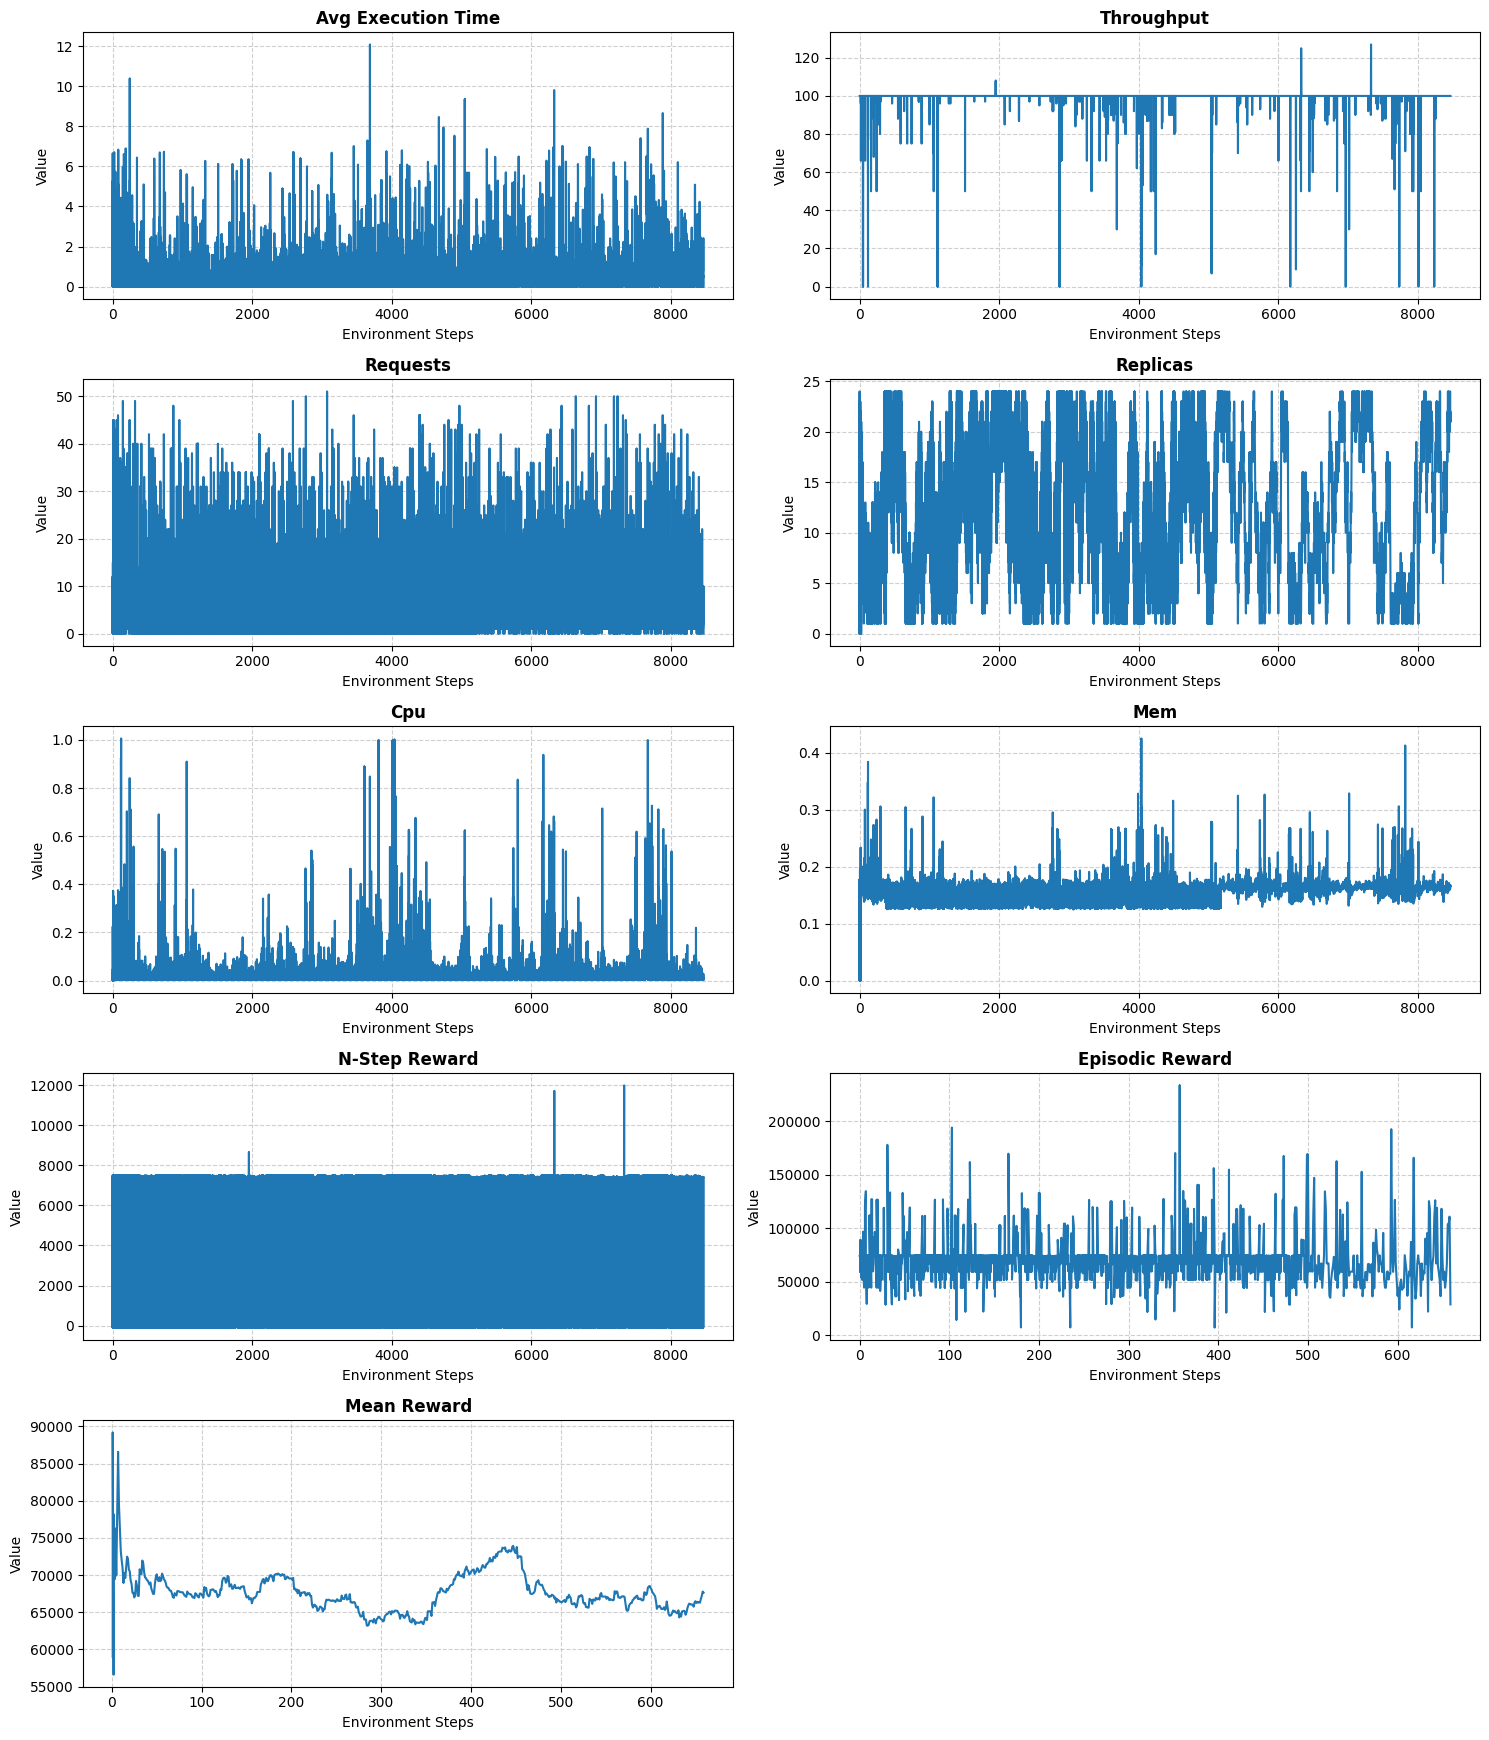


Plot successfully saved as → training_metrics_summary.png


In [6]:
import json
import glob
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.summary.summary_iterator import summary_iterator

# ── 1. Load JSON reward history ──────────────────────────────────────────────
# Looking specifically for the file named in your environment class
json_file = "reward_history_PPO_LSTM_Run3.json"

if os.path.exists(json_file):
    with open(json_file) as f:
        history = json.load(f)
    reward_df = pd.DataFrame({
        'episode': range(1, len(history['reward_history']) + 1),
        'episodic_reward': history['reward_history']
    })
    print(f"Loaded JSON: {json_file}  |  Episodes: {history['last_episode']}")
    display(reward_df.tail())
else:
    print(f"JSON file '{json_file}' not found.")
    reward_df = pd.DataFrame()

# ── 2. Load TensorBoard event logs ───────────────────────────────────────────
# Recursively search the logs/ directory for tfevent files
event_files = glob.glob("logs/**/events.out.tfevents.*", recursive=True)
print(f"\nFound {len(event_files)} TensorBoard event file(s)")

records = []
for ef in event_files:
    try:
        for event in summary_iterator(ef):
            for value in event.summary.value:
                # Extract the scalar values
                records.append({
                    'step': event.step,
                    'wall_time': event.wall_time,
                    'tag': value.tag,
                    'value': tf.make_ndarray(value.tensor).item() 
                             if value.HasField('tensor') 
                             else value.simple_value
                })
    except Exception as e:
        print(f"Skipping or partial read on {ef}: {e}")

events_df = pd.DataFrame(records)

if not events_df.empty:
    # Pivot so each metric tag becomes its own column, indexed by step
    pivot_df = (events_df
                .pivot_table(index='step', columns='tag', values='value', aggfunc='last')
                .reset_index())
    pivot_df.columns.name = None
    print(f"\nLogged tags : {events_df['tag'].unique().tolist()}")
    print(f"Total steps : {events_df['step'].nunique()}")
    display(pivot_df.tail())
else:
    print("No event data found.")
    pivot_df = pd.DataFrame()

# ── 3. Plotting the Custom Metrics ───────────────────────────────────────────
# These match the exact tags you wrote to tf.summary.scalar
plot_tags = [
    'avg_execution_time', 'throughput', 'requests', 'replicas', 
    'cpu', 'mem', 'n-step_reward', 'episodic_reward', 'mean_reward'
]

available_tags = [t for t in plot_tags if t in events_df.get('tag', pd.Series()).unique()]

if available_tags:
    cols = 2
    rows = math.ceil(len(available_tags) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
    axes = axes.flatten()

    for i, tag in enumerate(available_tags):
        # Filter data for the specific tag and sort by step
        subset = events_df[events_df['tag'] == tag].sort_values('step')
        
        axes[i].plot(subset['step'], subset['value'], linewidth=1.5, color='#1f77b4')
        axes[i].set_title(tag.replace('_', ' ').title(), fontweight='bold')
        axes[i].set_xlabel('Environment Steps')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, linestyle='--', alpha=0.6)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig("training_metrics_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot successfully saved as → training_metrics_summary.png")

Loaded JSON: reward_history_PPO_LSTM_Run3.json  |  Episodes: 659


,episode,episodic_reward
654,655,67178.80
655,656,103785.60
656,657,103879.63
657,658,110965.47
658,659,28924.43



Found 28 TensorBoard event file(s)

Logged tags : ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'action_feedback', 'n-step_reward', 'episodic_reward', 'mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss', 'reward summary']
Total steps : 8468


,step,action,action_feedback,avg_execution_time,cpu,episode,episodic_reward,mean_reward,mem,n-step_reward,...,time/fps,train/approx_kl,train/clip_fraction,train/clip_range,train/entropy_loss,train/explained_variance,train/learning_rate,train/loss,train/policy_gradient_loss,train/value_loss
8463,8463,0.0,0.0,0.802,0.0037,659.0,NaN,NaN,0.1612,-100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8464,8464,-2.0,1.0,2.423,0.0283,659.0,NaN,NaN,0.1645,7392.160156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8465,8465,-1.0,1.0,0.469,0.0195,659.0,NaN,NaN,0.1666,7402.330078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8466,8466,1.0,1.0,0.545,0.0169,659.0,NaN,NaN,0.1645,7392.020020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8467,8467,-1.0,1.0,0.000,0.0037,659.0,NaN,NaN,0.1665,7402.129883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


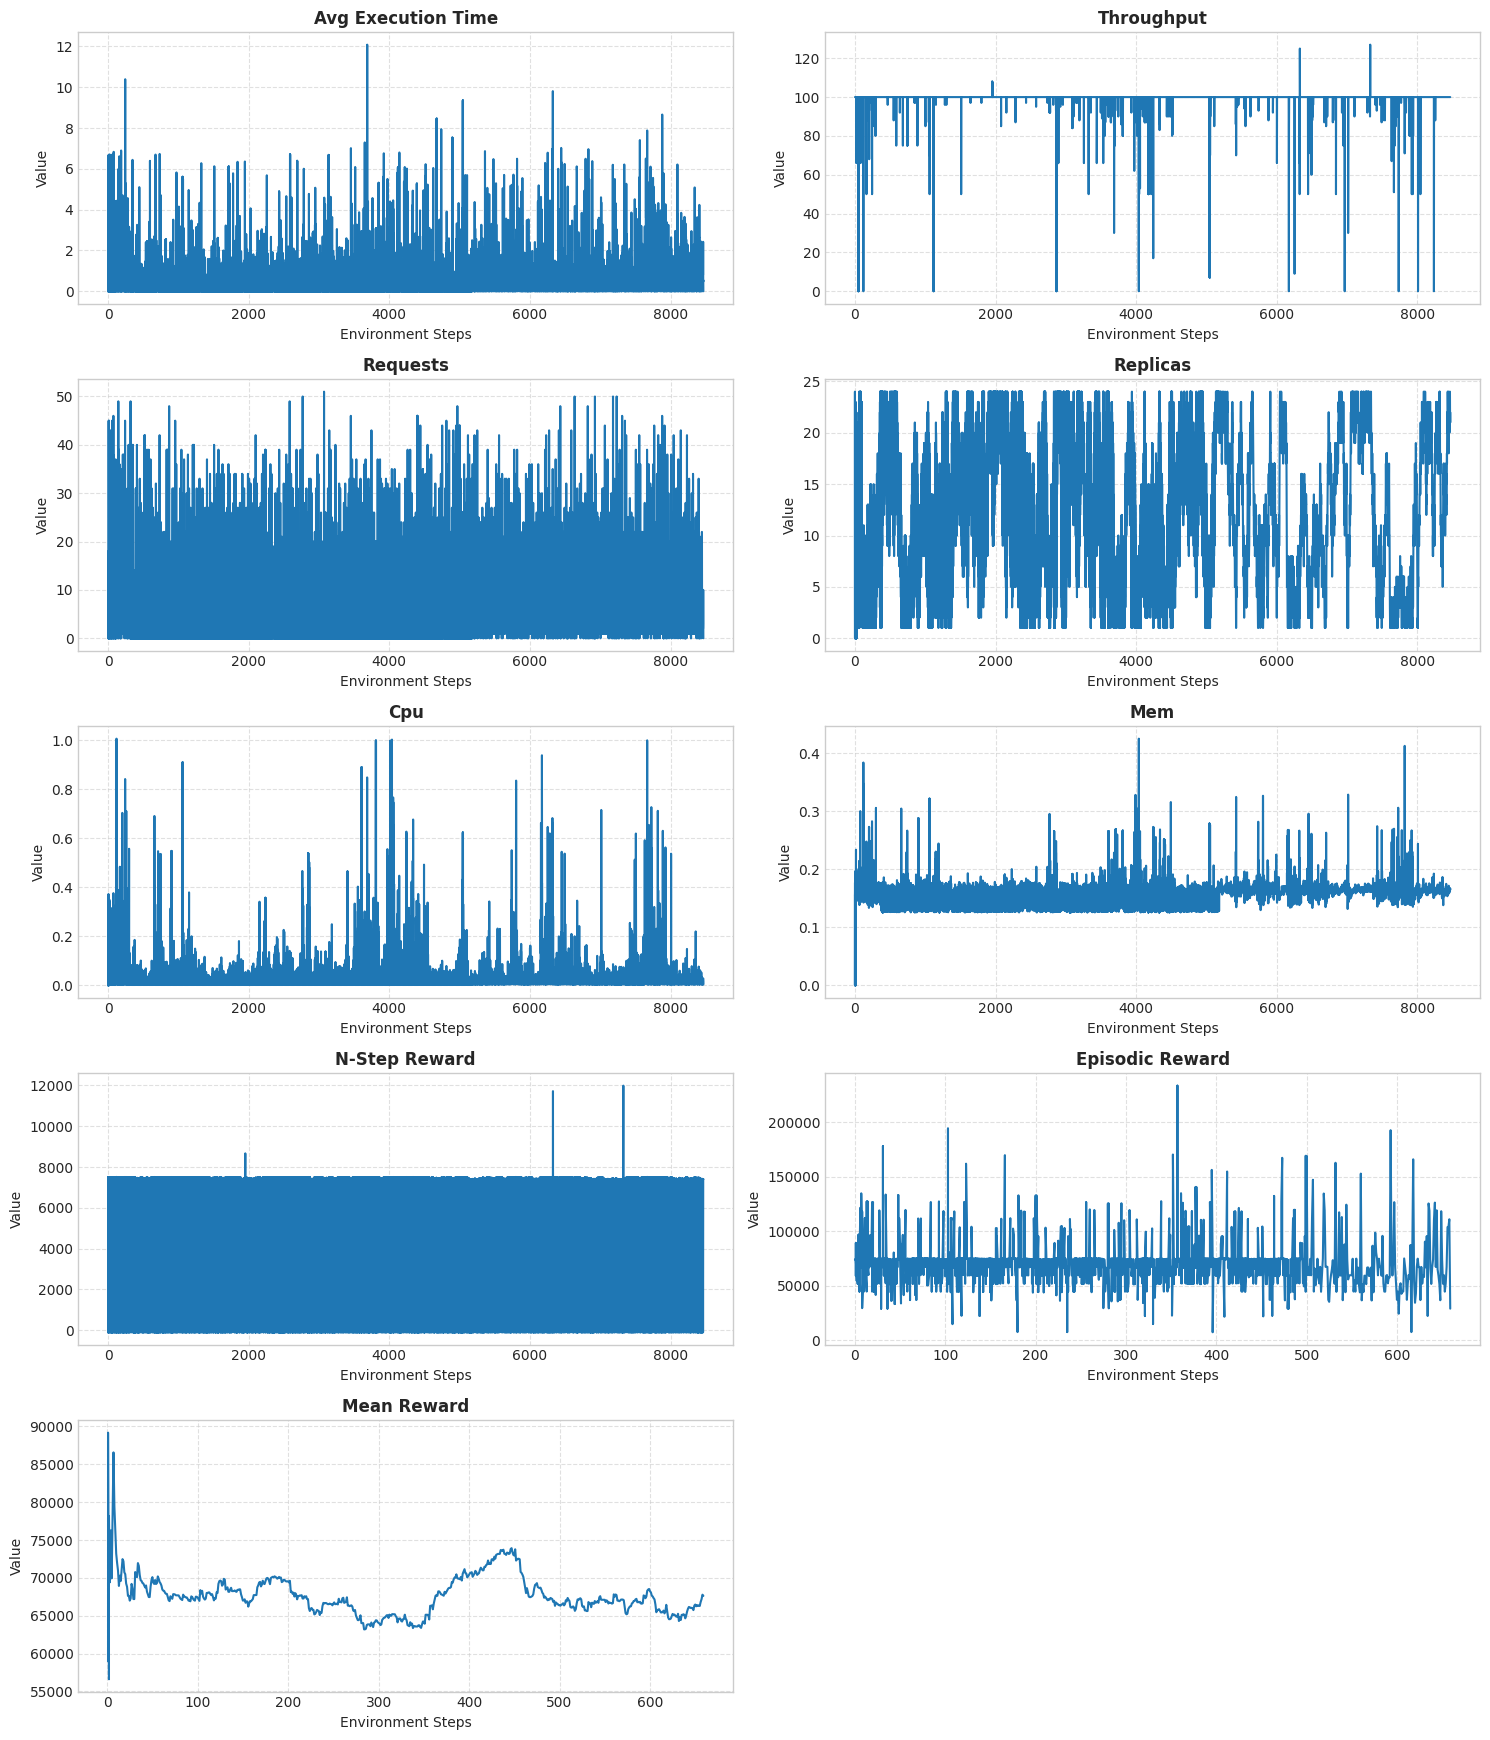


Plot successfully saved as → training_metrics_summary.png
Step metrics successfully saved to → training_metrics_steps.csv
Episode rewards successfully saved to → training_metrics_episodes.csv


In [11]:
import json
import glob
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.summary.summary_iterator import summary_iterator

# ── 1. Load JSON reward history ──────────────────────────────────────────────
json_file = "reward_history_PPO_LSTM_Run3.json"

if os.path.exists(json_file):
    with open(json_file) as f:
        history = json.load(f)
    reward_df = pd.DataFrame({
        'episode': range(1, len(history['reward_history']) + 1),
        'episodic_reward': history['reward_history']
    })
    print(f"Loaded JSON: {json_file}  |  Episodes: {history['last_episode']}")
    display(reward_df.tail())
else:
    print(f"JSON file '{json_file}' not found.")
    reward_df = pd.DataFrame()

# ── 2. Load TensorBoard event logs ───────────────────────────────────────────
event_files = glob.glob("logs/**/events.out.tfevents.*", recursive=True)
print(f"\nFound {len(event_files)} TensorBoard event file(s)")

records = []
for ef in event_files:
    try:
        for event in summary_iterator(ef):
            for value in event.summary.value:
                # Extract the scalar values
                records.append({
                    'step': event.step,
                    'wall_time': event.wall_time,
                    'tag': value.tag,
                    'value': tf.make_ndarray(value.tensor).item() 
                             if value.HasField('tensor') 
                             else value.simple_value
                })
    except Exception as e:
        print(f"Skipping or partial read on {ef}: {e}")

events_df = pd.DataFrame(records)

if not events_df.empty:
    # Pivot so each metric tag becomes its own column, indexed by step
    pivot_df = (events_df
                .pivot_table(index='step', columns='tag', values='value', aggfunc='last')
                .reset_index())
    pivot_df.columns.name = None
    print(f"\nLogged tags : {events_df['tag'].unique().tolist()}")
    print(f"Total steps : {events_df['step'].nunique()}")
    display(pivot_df.tail())
else:
    print("No event data found.")
    pivot_df = pd.DataFrame()

# ── 3. Plotting the Custom Metrics ───────────────────────────────────────────
plot_tags = [
    'avg_execution_time', 'throughput', 'requests', 'replicas', 
    'cpu', 'mem', 'n-step_reward', 'episodic_reward', 'mean_reward'
]

available_tags = [t for t in plot_tags if t in events_df.get('tag', pd.Series()).unique()]

if available_tags:
    cols = 2
    rows = math.ceil(len(available_tags) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
    axes = axes.flatten()

    for i, tag in enumerate(available_tags):
        subset = events_df[events_df['tag'] == tag].sort_values('step')
        
        axes[i].plot(subset['step'], subset['value'], linewidth=1.5, color='#1f77b4')
        axes[i].set_title(tag.replace('_', ' ').title(), fontweight='bold')
        axes[i].set_xlabel('Environment Steps')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, linestyle='--', alpha=0.6)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig("training_metrics_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot successfully saved as → training_metrics_summary.png")

# ── 4. Save Data to CSV / Excel ──────────────────────────────────────────────
# Save the step-by-step TensorBoard metrics
if not pivot_df.empty:
    step_metrics_csv = "training_metrics_steps.csv"
    pivot_df.to_csv(step_metrics_csv, index=False)
    print(f"Step metrics successfully saved to → {step_metrics_csv}")
    
    # Optional: Save to Excel if you have openpyxl installed
    # pivot_df.to_excel("training_metrics_steps.xlsx", index=False)

# Save the episode-by-episode JSON rewards
if not reward_df.empty:
    episode_metrics_csv = "training_metrics_episodes.csv"
    reward_df.to_csv(episode_metrics_csv, index=False)
    print(f"Episode rewards successfully saved to → {episode_metrics_csv}")

In [5]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.summary.summary_iterator import summary_iterator

# ── 1. Load JSON reward history ──────────────────────────────────────────────
json_file = "reward_history_PPO_LSTM_Run3.json"

if os.path.exists(json_file):
    with open(json_file) as f:
        history = json.load(f)
    reward_df = pd.DataFrame({
        'episode': range(1, len(history['reward_history']) + 1),
        'episodic_reward': history['reward_history']
    })
    print(f"Loaded JSON: {json_file}  |  Episodes: {history['last_episode']}")
    display(reward_df.tail())
else:
    print(f"JSON file '{json_file}' not found.")
    reward_df = pd.DataFrame()

# ── 2. Load TensorBoard event logs ───────────────────────────────────────────
event_files = glob.glob("logs/**/events.out.tfevents.1772634089.kuscu.496928.0.v2", recursive=True)
print(f"\nFound {len(event_files)} TensorBoard event file(s)")

records = []
for ef in event_files:
    try:
        for event in summary_iterator(ef):
            for value in event.summary.value:
                records.append({
                    'step': event.step,
                    'wall_time': event.wall_time,
                    'tag': value.tag,
                    'value': tf.make_ndarray(value.tensor).item() 
                             if value.HasField('tensor') 
                             else value.simple_value
                })
    except Exception as e:
        print(f"Skipping or partial read on {ef}: {e}")

events_df = pd.DataFrame(records)

if not events_df.empty:
    pivot_df = (events_df
                .pivot_table(index='step', columns='tag', values='value', aggfunc='last')
                .reset_index())
    pivot_df.columns.name = None
    print(f"\nLogged tags : {events_df['tag'].unique().tolist()}")
    print(f"Total steps : {events_df['step'].nunique()}")
    display(pivot_df.tail())
else:
    print("No event data found.")
    pivot_df = pd.DataFrame()

# ── 3. Publication-Style Plots (Fig. 4 recreation) ───────────────────────────

output_dir = "metric_plots"
os.makedirs(output_dir, exist_ok=True)

# Shared style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

# ── (a) Mean Episodic Reward ──
if 'mean_reward' in events_df['tag'].values or 'episodic_reward' in events_df['tag'].values:
    tag = 'mean_reward' if 'mean_reward' in events_df['tag'].values else 'episodic_reward'
    subset = events_df[events_df['tag'] == tag].sort_values('step')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(subset['step'], subset['value'], linewidth=2.0, color='#1f77b4', label='PPO-LSTM')
    
    # Optional: smoothed line
    window = max(1, len(subset) // 50)
    smoothed = subset['value'].rolling(window=window, min_periods=1).mean()
    ax.plot(subset['step'], smoothed, linewidth=2.5, color='#d62728', linestyle='--', label='Smoothed')
    
    ax.set_title('(a) Mean Episodic Reward', fontweight='bold', fontsize=18)
    ax.set_xlabel('Environment Steps', fontsize=15)
    ax.set_ylabel('Mean Reward', fontsize=15)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, frameon=True, edgecolor='black')
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, 'fig4a_mean_episodic_reward.png'), dpi=200, bbox_inches='tight')
    plt.close(fig)
    print("Saved → fig4a_mean_episodic_reward.png")

# ── (b) Throughput ──
if 'throughput' in events_df['tag'].values:
    subset = events_df[events_df['tag'] == 'throughput'].sort_values('step')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(subset['step'], subset['value'], linewidth=2.0, color='#2ca02c', label='Throughput')
    
    window = max(1, len(subset) // 50)
    smoothed = subset['value'].rolling(window=window, min_periods=1).mean()
    ax.plot(subset['step'], smoothed, linewidth=2.5, color='#d62728', linestyle='--', label='Smoothed')
    
    ax.set_title('(b) Throughput', fontweight='bold', fontsize=18)
    ax.set_xlabel('Environment Steps', fontsize=15)
    ax.set_ylabel('Throughput (req/s)', fontsize=15)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, frameon=True, edgecolor='black')
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, 'fig4b_throughput.png'), dpi=200, bbox_inches='tight')
    plt.close(fig)
    print("Saved → fig4b_throughput.png")

# ── (c) Throughput vs Execution Time ──
if 'throughput' in events_df['tag'].values and 'avg_execution_time' in events_df['tag'].values:
    tp = events_df[events_df['tag'] == 'throughput'].sort_values('step')
    et = events_df[events_df['tag'] == 'avg_execution_time'].sort_values('step')
    
    # Merge on step so both metrics align
    merged = pd.merge(
        tp[['step', 'value']].rename(columns={'value': 'throughput'}),
        et[['step', 'value']].rename(columns={'value': 'exec_time'}),
        on='step', how='inner'
    )
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Throughput on left y-axis
    color1 = '#2ca02c'
    ax1.plot(merged['step'], merged['throughput'], linewidth=2.0, color=color1, label='Throughput')
    ax1.set_xlabel('Environment Steps', fontsize=15)
    ax1.set_ylabel('Throughput (req/s)', fontsize=15, color=color1)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=13)
    ax1.tick_params(axis='x', labelsize=13)
    
    # Execution time on right y-axis
    ax2 = ax1.twinx()
    color2 = '#ff7f0e'
    ax2.plot(merged['step'], merged['exec_time'], linewidth=2.0, color=color2, label='Avg Execution Time')
    ax2.set_ylabel('Avg Execution Time (s)', fontsize=15, color=color2)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=13)
    
    ax1.set_title('(c) Throughput vs Execution Time', fontweight='bold', fontsize=18)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=13, frameon=True, edgecolor='black', loc='upper left')
    
    ax1.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, 'fig4c_throughput_vs_exectime.png'), dpi=200, bbox_inches='tight')
    plt.close(fig)
    print("Saved → fig4c_throughput_vs_exectime.png")

# Reset rcParams to defaults after plotting
plt.rcParams.update(plt.rcParamsDefault)
# ── 4. Save Data to CSV ──────────────────────────────────────────────────────
if not pivot_df.empty:
    step_metrics_csv = "training_metrics_steps.csv"
    pivot_df.to_csv(step_metrics_csv, index=False)
    print(f"\nStep metrics successfully saved to → {step_metrics_csv}")

if not reward_df.empty:
    episode_metrics_csv = "training_metrics_episodes.csv"
    reward_df.to_csv(episode_metrics_csv, index=False)
    print(f"Episode rewards successfully saved to → {episode_metrics_csv}")

Loaded JSON: reward_history_PPO_LSTM_Run3.json  |  Episodes: 659


,episode,episodic_reward
654,655,67178.80
655,656,103785.60
656,657,103879.63
657,658,110965.47
658,659,28924.43



Found 1 TensorBoard event file(s)

Logged tags : ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'action_feedback', 'n-step_reward', 'episodic_reward', 'mean_reward']
Total steps : 8468


,step,action,action_feedback,avg_execution_time,cpu,episode,episodic_reward,mean_reward,mem,n-step_reward,replicas,requests,throughput
8463,8463,0.0,0.0,0.802,0.0037,659.0,NaN,NaN,0.1612,-100.000000,24.0,2.0,100.0
8464,8464,-2.0,1.0,2.423,0.0283,659.0,NaN,NaN,0.1645,7392.160156,22.0,3.0,100.0
8465,8465,-1.0,1.0,0.469,0.0195,659.0,NaN,NaN,0.1666,7402.330078,21.0,10.0,100.0
8466,8466,1.0,1.0,0.545,0.0169,659.0,NaN,NaN,0.1645,7392.020020,22.0,2.0,100.0
8467,8467,-1.0,1.0,0.000,0.0037,659.0,NaN,NaN,0.1665,7402.129883,21.0,0.0,100.0


Saved → fig4a_mean_episodic_reward.png
Saved → fig4b_throughput.png
Saved → fig4c_throughput_vs_exectime.png

Step metrics successfully saved to → training_metrics_steps.csv
Episode rewards successfully saved to → training_metrics_episodes.csv


In [3]:
import os
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 1. Define the path to your log directory
# Replace with the specific datetime folder generated by your env
# Example: log_path = 'logs/evaluation/20260308-231658/PPO_LSTM_Run1_2'
log_path = 'logs/evaluation/20260306-195903/PPO_LSTM_Run1_1' 

# 2. Load the event accumulator
print(f"Loading events from: {log_path}")
event_acc = EventAccumulator(log_path)
event_acc.Reload()

# 3. Extract scalar tags (avg_execution_time, throughput, episodic_reward, etc.)
tags = event_acc.Tags().get('scalars', [])
log_data = []

for tag in tags:
    for event in event_acc.Scalars(tag):
        log_data.append({
            'wall_time': pd.to_datetime(event.wall_time, unit='s'),
            'step': event.step,
            'metric': tag,
            'value': event.value
        })

# 4. Convert to a Pandas DataFrame
df = pd.DataFrame(log_data)

# 5. Pivot the table so each metric has its own column (indexed by step)
if not df.empty:
    df_pivoted = df.pivot(index='step', columns='metric', values='value')
    display(df_pivoted.head())
    display(df_pivoted.describe())
else:
    print("No scalar data found. Ensure the path points directly to the folder containing the 'events.out.tfevents' file.")

# --- Bonus: If you just want the visual TensorBoard UI inside Jupyter, uncomment below ---
# %load_ext tensorboard
# %tensorboard --logdir logs/evaluation/

Loading events from: logs/evaluation/20260306-195903/PPO_LSTM_Run1_1


DirectoryDeletedError: Directory logs/evaluation/20260306-195903/PPO_LSTM_Run1_1 has been permanently deleted

In [ ]:
import os
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 1. Define the path to your specific log directory
# Update this to match your latest run folder
log_dir = 'scaling-agents/LSTM-PPO/logs/20260304-142129/${PPO_LSTM_Run2}'

def extract_tensorboard_data(log_path):
    # Initialize the accumulator and load the data
    event_acc = EventAccumulator(log_path, size_guidance={'scalars': 0})
    event_acc.Reload()

    # Dictionary to hold all the metrics
    metrics_data = {}

    # 2. Loop through all scalar tags logged in the environment
    for tag in event_acc.Tags()['scalars']:
        events = event_acc.Scalars(tag)
        
        # Extract steps and values
        steps = [event.step for event in events]
        values = [event.value for event in events]
        
        # Create a dataframe for this specific tag
        df = pd.DataFrame({'step': steps, tag: values})
        df.set_index('step', inplace=True)
        metrics_data[tag] = df

    # 3. Merge all metric dataframes on the 'step' index
    if not metrics_data:
        print("No scalar data found in the provided directory.")
        return None

    # Concatenate all dataframes horizontally
    final_df = pd.concat(metrics_data.values(), axis=1)
    
    # Sort by step to ensure timeline is correct
    final_df.sort_index(inplace=True)
    final_df.reset_index(inplace=True)
    
    return final_df

# Execute extraction
training_df = extract_tensorboard_data(log_dir)

if training_df is not None:
    # 4. Export to CSV and Excel
    csv_filename = 'ppo_training_results.csv'
    excel_filename = 'ppo_training_results.xlsx'
    
    training_df.to_csv(csv_filename, index=False)
    training_df.to_excel(excel_filename, index=False)
    
    print(f"Data successfully exported to {csv_filename} and {excel_filename}")
    display(training_df.head(10)) # Preview in Jupyter

No scalar data found in the provided directory.
